In [30]:
from google.colab import files
files.upload()

Saving Combined_Stock_Data.csv to Combined_Stock_Data (2).csv


{'Combined_Stock_Data (2).csv': b'Ticker,Date,Close/Last,Volume,Open,High,Low\nAAPL,04/02/2025,$223.89,,$221.315,NaN,NULL\nAMD,04/02/2025,$102.96,20793990,$101.52,$104.185,$100.76\nAMZN,04/02/2025,$196.01,53679200,$187.66,$198.34,$187.66\nCSCO,04/02/2025,$61.82,18610690,$61.195,$61.87,$61.10\nMETA,04/02/2025,$583.93,13470780,$574.91,$592.66,$573.36\nMSFT,04/02/2025,$382.14,16092560,$377.965,$385.08,$376.62\nNFLX,04/02/2025,$935.52,3256886,$923.00,$949.5479,$916.11\nQCOM,04/02/2025,$154.08,5377181,$150.79,$155.46,$150.37\nSBUX,04/02/2025,$99.41,,$97.41,$99.75,$97.41\nTSLA,04/02/2025,$282.76,212787800,$254.60,NaN,$251.27\nAAPL,04/01/2025,$223.19,36412740,$219.805,$223.68,NULL\nAMD,04/01/2025,$102.78,23523230,$102.16,$102.83,$100.93\nAMZN,04/01/2025,$192.17,41267320,$187.86,$193.93,$187.20\nCSCO,04/01/2025,$61.80,17381450,$61.38,$62.04,$61.06\nMETA,04/01/2025,$586.00,12836570,$570.84,$589.91,$570.00\nMSFT,04/01/2025,$382.19,19689500,$374.65,$382.85,$373.23\nNFLX,04/01/2025,$928.38,,$927.5

In [31]:
# =========================
# SECTION 1 — Imports & Setup
# =========================

# Data handling (tables, loading CSV, cleaning, sorting)
import pandas as pd

# Numerical operations (arrays, math utilities)
import numpy as np
import math

# Plotting (visual evaluation)
import matplotlib.pyplot as plt

# Sklearn tools:
# - Scaling (only for Linear Regression features)
from sklearn.preprocessing import StandardScaler

# - Regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# - Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [32]:
# =========================
# SECTION 2 — Load & Inspect Data
# =========================

df = pd.read_csv("Combined_Stock_Data.csv")

print(df.head())                # first 5 rows
print(df.columns)               # column names
print(df.dtypes)                # data types
print(df.isna().sum())          # missing values count


  Ticker        Date Close/Last      Volume      Open      High      Low
0   AAPL  04/02/2025    $223.89         NaN  $221.315       NaN      NaN
1    AMD  04/02/2025    $102.96  20793990.0   $101.52  $104.185  $100.76
2   AMZN  04/02/2025    $196.01  53679200.0   $187.66   $198.34  $187.66
3   CSCO  04/02/2025     $61.82  18610690.0   $61.195    $61.87   $61.10
4   META  04/02/2025    $583.93  13470780.0   $574.91   $592.66  $573.36
Index(['Ticker', 'Date', 'Close/Last', 'Volume', 'Open', 'High', 'Low'], dtype='object')
Ticker         object
Date           object
Close/Last     object
Volume        float64
Open           object
High           object
Low            object
dtype: object
Ticker          0
Date            0
Close/Last      0
Volume        314
Open            0
High          279
Low           251
dtype: int64


In [33]:
# =========================
# SECTION 3 — Date Handling & Sorting
# =========================

df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y", errors="coerce")

df = df.sort_values("Date", ascending=True)
df = df.reset_index(drop=True)


In [34]:
# =========================
# SECTION 4 — Remove Unused Columns
# =========================

# IMPORTANT: The file contains multiple tickers; choose ONE ticker to form a valid single time series.
# This avoids mixing different companies and avoids lag leakage across different tickers.
df = df[df["Ticker"] == "AMD"].copy()

# Convert money columns from "$123.45" into float 123.45
money_cols = ["Close/Last", "Open", "High", "Low"]
for c in money_cols:
    df[c] = df[c].astype(str).str.replace(r"[$,]", "", regex=True)
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Sort again after filtering
df = df.sort_values("Date").reset_index(drop=True)

# Drop categorical ID column (Ticker)
df = df.drop(columns=["Ticker"])


In [35]:
# =========================
# SECTION 5 — Feature Engineering (Lag Features)
# =========================

# Lag features use yesterday's market information to predict today's closing price.
# This matches real-life forecasting, because you would only know prior-day values at prediction time.

df["Open_lag1"] = df["Open"].shift(1)
df["High_lag1"] = df["High"].shift(1)
df["Low_lag1"]  = df["Low"].shift(1)
df["Volume_lag1"] = df["Volume"].shift(1)

# Remove rows made incomplete by lagging (first row becomes NaN)
df = df.dropna().reset_index(drop=True)


In [36]:
# =========================
# SECTION 6 — Define Features & Target
# =========================

X = df[["Open_lag1", "High_lag1", "Low_lag1", "Volume_lag1"]]
y = df["Close/Last"]


In [37]:
# =========================
# SECTION 7 — Train–Test Split (Chronological)
# =========================

split_index = int(len(df) * 0.70)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

dates_test = df["Date"].iloc[split_index:]  # only for plotting


In [38]:
# =========================
# SECTION 8 — Feature Scaling (Linear Regression Only)
# =========================

scaler = StandardScaler()

# Fit ONLY on training features (prevents test leakage)
X_train_scaled = scaler.fit_transform(X_train)

# Transform test using same scaler parameters
X_test_scaled = scaler.transform(X_test)


In [39]:
# =========================
# SECTION 9 — Model 1: Linear Regression
# =========================

lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)

lin_pred = lin_model.predict(X_test_scaled)


In [40]:
# =========================
# SECTION 10 — Model 2: Random Forest Regressor
# =========================

rf_model = RandomForestRegressor(
    n_estimators=300,      # reasonable number of trees
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)


In [41]:
# =========================
# SECTION 11 — Model Evaluation
# =========================

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

lin_mae, lin_rmse, lin_r2 = evaluate(y_test, lin_pred)
rf_mae, rf_rmse, rf_r2 = evaluate(y_test, rf_pred)

print("Linear Regression:", lin_mae, lin_rmse, lin_r2)
print("Random Forest:", rf_mae, rf_rmse, rf_r2)

# Manual comparison table
print("\nComparison Table")
print("Model\t\t\tMAE\t\tRMSE\t\tR2")
print(f"Linear Regression\t{lin_mae:.3f}\t\t{lin_rmse:.3f}\t\t{lin_r2:.3f}")
print(f"Random Forest\t\t{rf_mae:.3f}\t\t{rf_rmse:.3f}\t\t{rf_r2:.3f}")


Linear Regression: 3.0700784531766243 3.7729922703069745 0.8396578503105467
Random Forest: 18.111236723164236 20.429622316408523 -3.701068145574144

Comparison Table
Model			MAE		RMSE		R2
Linear Regression	3.070		3.773		0.840
Random Forest		18.111		20.430		-3.701


In [42]:
# =========================
# BONUS: Hyperparameter Tuning (Random Forest)
# =========================

# Tuned Random Forest with controlled complexity
rf_tuned = RandomForestRegressor(
    n_estimators=200,        # more stable than small forests
    max_depth=10,            # limits overfitting
    min_samples_leaf=5,      # smoother predictions
    random_state=42
)

rf_tuned.fit(X_train, y_train)
rf_tuned_pred = rf_tuned.predict(X_test)

# Evaluate tuned model
rf_tuned_mae = mean_absolute_error(y_test, rf_tuned_pred)
rf_tuned_rmse = math.sqrt(mean_squared_error(y_test, rf_tuned_pred))
rf_tuned_r2 = r2_score(y_test, rf_tuned_pred)

print("Random Forest (Tuned):")
print("MAE:", rf_tuned_mae)
print("RMSE:", rf_tuned_rmse)
print("R²:", rf_tuned_r2)


Random Forest (Tuned):
MAE: 19.884414162609023
RMSE: 22.02009142354779
R²: -4.4615272692135255


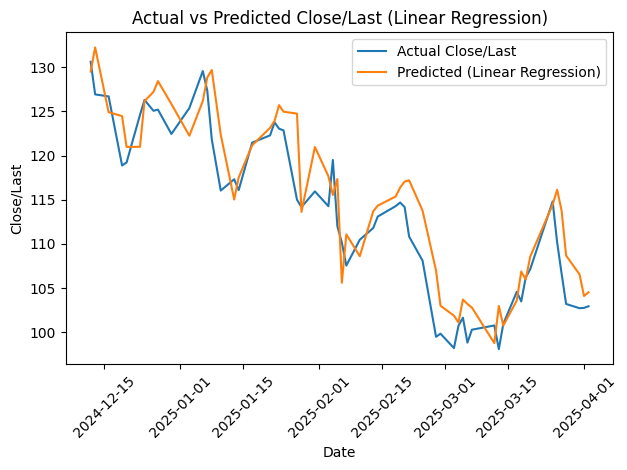

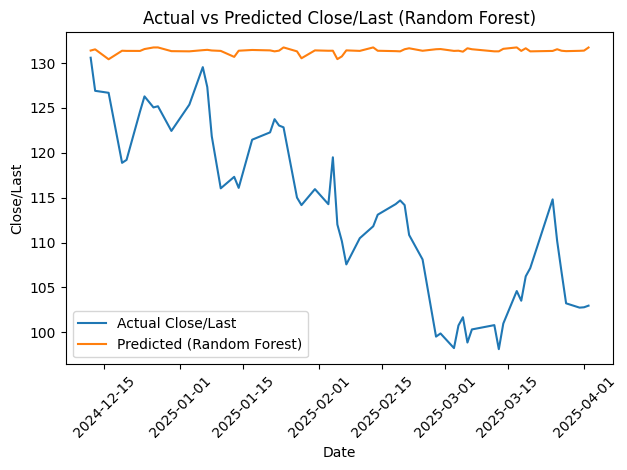

In [43]:
# =========================
# SECTION 12 — Visualisation: Predicted vs Actual
# =========================

plt.figure()
plt.plot(dates_test, y_test.values, label="Actual Close/Last")
plt.plot(dates_test, lin_pred, label="Predicted (Linear Regression)")
plt.title("Actual vs Predicted Close/Last (Linear Regression)")
plt.xlabel("Date")
plt.ylabel("Close/Last")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(dates_test, y_test.values, label="Actual Close/Last")
plt.plot(dates_test, rf_pred, label="Predicted (Random Forest)")
plt.title("Actual vs Predicted Close/Last (Random Forest)")
plt.xlabel("Date")
plt.ylabel("Close/Last")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


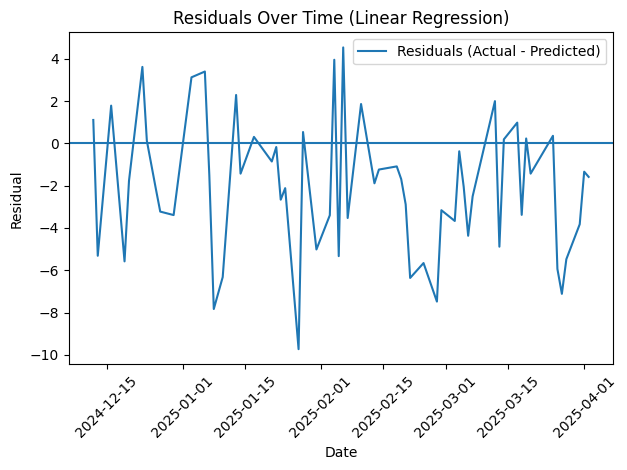

In [44]:
# =========================
# SECTION 12 — Visualisation: Residual Plot
# =========================

residuals = y_test.values - lin_pred

plt.figure()
plt.plot(dates_test, residuals, label="Residuals (Actual - Predicted)")
plt.axhline(0)
plt.title("Residuals Over Time (Linear Regression)")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
